# XGBoost & LightGBM — Gradient Boosting

**Goal:** Master the two most-used gradient boosting libraries — the current state-of-the-art on tabular data.

**Why it matters:**
- On tabular data, **gradient boosting beats neural networks** in most benchmarks.
- Fast, accurate, handles missing values natively, does feature selection automatically.
- This is the model you'll actually use in production.

**Prerequisite:** [03-knn-svm.ipynb](./03-knn-svm.ipynb)

**Dataset:** Titanic 
---

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

print("Setup complete.")

Setup complete.


In [9]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["HasCabin"] = df["Cabin"].notna().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
         "Fare", "Embarked", "HasCabin", "FamilySize", "IsAlone"]]

X = df.drop(columns=["Survived"])
y = df["Survived"]

numeric_features = ["Age", "SibSp", "Parch", "Fare", "HasCabin", "FamilySize", "IsAlone"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 10), Test: (179, 10)


In [10]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


##  The Idea Behind Gradient Boosting

### From Random Forest to Boosting

**Random Forest:** trains many trees **in parallel**, each on a bootstrap sample. Averages predictions.

**Gradient Boosting:** trains trees **sequentially**. Each new tree fixes the mistakes of the previous ensemble.

Analogy:
- Random Forest = asking 100 experts independently, then voting
- Gradient Boosting = one expert starts, a second expert studies their mistakes and corrects, a third corrects the second, etc.

### The Math (Simplified)

1. Start with a constant prediction: `F₀(x) = mean(y)` (for regression)
2. For iteration m = 1, 2, ..., M:
   - Compute residuals: `rᵢ = yᵢ - F_{m-1}(xᵢ)`
   - Fit a tree `hₘ(x)` to predict the residuals
   - Update: `Fₘ(x) = F_{m-1}(x) + η · hₘ(x)` where η = learning rate
3. Final prediction: `F_M(x)`

### Key Hyperparameters

| Parameter | What it does | Risk if wrong |
|-----------|-------------|---------------|
| `n_estimators` | Number of trees | Too many → overfit |
| `learning_rate` | Shrinkage per tree (η) | Too high → overfit, too low → slow |
| `max_depth` | Tree depth | Too deep → overfit |
| `min_child_weight` | Min samples in leaf | Too low → overfit |
| `subsample` | Row sampling per tree | < 1.0 → regularization |
| `colsample_bytree` | Feature sampling per tree | < 1.0 → regularization |
| `reg_alpha` | L1 regularization | Higher → sparser |
| `reg_lambda` | L2 regularization | Higher → smoother |

### The Secret Weapon: `learning_rate × n_estimators`

These two are coupled. Small learning rate + many trees ≈ large learning rate + few trees.
Common recipe: `learning_rate=0.1` + `n_estimators=100-1000`, or `learning_rate=0.01` + `n_estimators=1000-5000`.

### XGBoost vs LightGBM — What's Different?

| Aspect | XGBoost | LightGBM |
|--------|---------|----------|
| Tree growth | Level-wise (depth-first) | Leaf-wise (best-first) |
| Speed | Slower | Faster on large data |
| Accuracy | Excellent | Excellent |
| Memory | Higher | Lower |
| Native categoricals | Yes (recent versions) | Yes (very good) |
| When to choose | Small/medium data, stability | Large data, speed |

In practice: try both, pick by CV score.

---

In [11]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_alpha=0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        use_label_encoder=False,
        verbosity=2,

    )),
])

t0 = time.time()
xgb_pipe.fit(X_train, y_train)
xgb_time = time.time() - t0

y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

print("=== XGBoost (baseline) ===")
print(f"Train time: {xgb_time:.2f}s")
print(f"Train acc : {xgb_pipe.score(X_train, y_train):.4f}")
print(f"Test acc  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_xgb):.4f}")

[14:45:23] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (712, 15, 10680).


c:\Users\Online\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:45:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost (baseline) ===
Train time: 0.56s
Train acc : 0.9284
Test acc  : 0.7877
ROC-AUC   : 0.8250
F1        : 0.7121


In [12]:
lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=10,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )),
])

t0 = time.time()
lgbm_pipe.fit(X_train, y_train)
lgbm_time = time.time() - t0

y_pred_lgbm = lgbm_pipe.predict(X_test)
y_proba_lgbm = lgbm_pipe.predict_proba(X_test)[:, 1]

print("=== LightGBM (baseline) ===")
print(f"Train time: {lgbm_time:.2f}s")
print(f"Train acc : {lgbm_pipe.score(X_train, y_train):.4f}")
print(f"Test acc  : {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_lgbm):.4f}")

=== LightGBM (baseline) ===
Train time: 0.21s
Train acc : 0.9775
Test acc  : 0.7877
ROC-AUC   : 0.8376
F1        : 0.7206


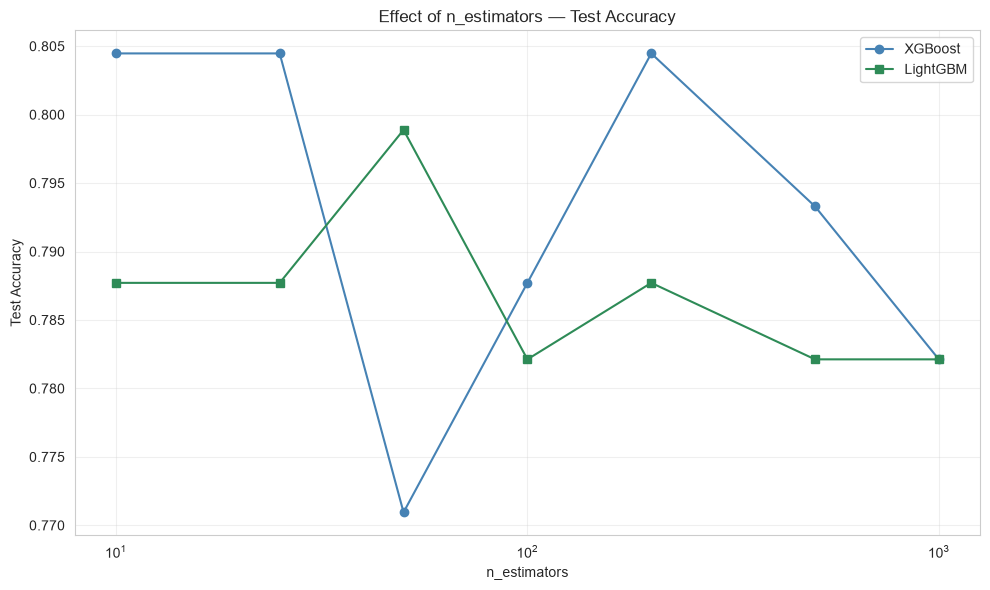

n=  10  XGB: 0.8045  LGBM: 0.7877
n=  25  XGB: 0.8045  LGBM: 0.7877
n=  50  XGB: 0.7709  LGBM: 0.7989
n= 100  XGB: 0.7877  LGBM: 0.7821
n= 200  XGB: 0.8045  LGBM: 0.7877
n= 500  XGB: 0.7933  LGBM: 0.7821
n=1000  XGB: 0.7821  LGBM: 0.7821


In [13]:
# How many trees is enough?
n_range = [10, 25, 50, 100, 200, 500, 1000]
xgb_test, lgbm_test = [], []

for n in n_range:
    xgb = Pipeline([("preprocessor", preprocessor),
                    ("model", XGBClassifier(n_estimators=n, learning_rate=0.1,
                                            random_state=42, n_jobs=-1,
                                            verbosity=0, eval_metric="logloss"))])
    xgb.fit(X_train, y_train)
    xgb_test.append(xgb.score(X_test, y_test))

    lgbm = Pipeline([("preprocessor", preprocessor),
                     ("model", LGBMClassifier(n_estimators=n, learning_rate=0.1,
                                              random_state=42, n_jobs=-1,
                                              verbose=-1))])
    lgbm.fit(X_train, y_train)
    lgbm_test.append(lgbm.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_range, xgb_test, "o-", label="XGBoost", color="steelblue")
plt.plot(n_range, lgbm_test, "s-", label="LightGBM", color="seagreen")
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Effect of n_estimators — Test Accuracy")
plt.xscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for n, xs, ls in zip(n_range, xgb_test, lgbm_test):
    print(f"n={n:4d}  XGB: {xs:.4f}  LGBM: {ls:.4f}")

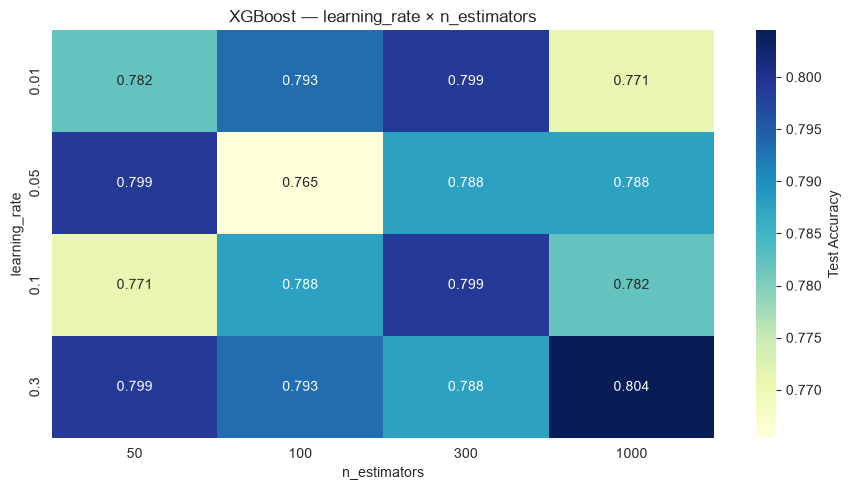

In [14]:
# The learning_rate × n_estimators tradeoff
lr_range = [0.01, 0.05, 0.1, 0.3]
n_range = [50, 100, 300, 1000]

results = []
for lr in lr_range:
    for n in n_range:
        xgb = Pipeline([("preprocessor", preprocessor),
                        ("model", XGBClassifier(n_estimators=n, learning_rate=lr,
                                                max_depth=6, random_state=42,
                                                n_jobs=-1, verbosity=0,
                                                eval_metric="logloss"))])
        xgb.fit(X_train, y_train)
        results.append({"lr": lr, "n": n, "acc": xgb.score(X_test, y_test)})

res_df = pd.DataFrame(results)
pivot = res_df.pivot(index="lr", columns="n", values="acc")

plt.figure(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt=".3f",
    # annot=True → write value inside each cell
    # fmt=".3f" → 3 decimal places (floats). Options:
    #   "d" for int, ".1%" for percentage, ".2e" for scientific
    cmap="YlGnBu",
    cbar_kws={"label": "Test Accuracy"},
)
plt.title("XGBoost — learning_rate × n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.tight_layout()
plt.show()

## Tuning with GridSearchCV

Boosting has many hyperparameters. We tune the most impactful ones.

**Tip:** Tune in order of impact: `learning_rate` × `n_estimators` → `max_depth` → regularization.

eval_metric="",
  - eval_metric="logloss" → metric reported during training.
  - "logloss": default for binary classification
  - "auc": area under ROC → often better for imbalanced
  - "error": misclassification rate
        

In [16]:
xgb_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(random_state=42, n_jobs=-1,
                            verbosity=0, eval_metric="logloss")),
])

xgb_grid = {
    "model__n_estimators": [100, 300],
    
    "model__learning_rate": [0.05, 0.1],
    
    "model__max_depth": [3, 6, 9],
    
    "model__subsample": [0.8, 1.0],
    
}

xgb_search = GridSearchCV(
    estimator=xgb_full,
    param_grid=xgb_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
xgb_search.fit(X_train, y_train)
print(f"\nXGBoost tuning took {time.time()-t0:.1f}s")
print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

XGBoost tuning took 52.2s
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best CV ROC-AUC: 0.8800


In [17]:
lgbm_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
])

lgbm_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__min_child_samples": [5, 20],
    
}

lgbm_search = GridSearchCV(
    estimator=lgbm_full,
    param_grid=lgbm_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
lgbm_search.fit(X_train, y_train)
print(f"\nLightGBM tuning took {time.time()-t0:.1f}s")
print(f"Best params: {lgbm_search.best_params_}")
print(f"Best CV ROC-AUC: {lgbm_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

LightGBM tuning took 51.9s
Best params: {'model__learning_rate': 0.05, 'model__min_child_samples': 20, 'model__n_estimators': 100, 'model__num_leaves': 15}
Best CV ROC-AUC: 0.8794


In [18]:
best_xgb = xgb_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

print("=== Tuned XGBoost ===")
y_pred_xgb_best = best_xgb.predict(X_test)
y_proba_xgb_best = best_xgb.predict_proba(X_test)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_best):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_xgb_best):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_xgb_best):.4f}")

print("\n=== Tuned LightGBM ===")
y_pred_lgbm_best = best_lgbm.predict(X_test)
y_proba_lgbm_best = best_lgbm.predict_proba(X_test)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm_best):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_lgbm_best):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_lgbm_best):.4f}")

=== Tuned XGBoost ===
Accuracy: 0.8045
ROC-AUC : 0.8221
F1      : 0.7107

=== Tuned LightGBM ===
Accuracy: 0.7709
ROC-AUC : 0.8263
F1      : 0.6822


In [19]:
# Baselines from all previous notebooks
logreg = Pipeline([("preprocessor", preprocessor),
                   ("model", LogisticRegression(max_iter=1000, random_state=42))]).fit(X_train, y_train)

rf = Pipeline([("preprocessor", preprocessor),
               ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]).fit(X_train, y_train)

# Import KNN & SVM from previous notebook logic (retrain quickly)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

knn = Pipeline([("preprocessor", preprocessor),
                ("model", KNeighborsClassifier(n_neighbors=11, weights="distance", n_jobs=-1))]).fit(X_train, y_train)

svm = Pipeline([("preprocessor", preprocessor),
                ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))]).fit(X_train, y_train)

models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "KNN (k=11, distance)": knn,
    "SVM (rbf, C=1)": svm,
    "XGBoost (default)": xgb_pipe,
    "XGBoost (tuned)": best_xgb,
    "LightGBM (default)": lgbm_pipe,
    "LightGBM (tuned)": best_lgbm,
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

leaderboard = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
print(leaderboard.round(4).to_string(index=False))

c:\Users\Online\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


               Model  Accuracy     F1  ROC-AUC
 Logistic Regression    0.8156 0.7442   0.8422
  LightGBM (default)    0.7877 0.7206   0.8376
       Random Forest    0.7933 0.7218   0.8331
    LightGBM (tuned)    0.7709 0.6822   0.8263
   XGBoost (default)    0.7877 0.7121   0.8250
     XGBoost (tuned)    0.8045 0.7107   0.8221
KNN (k=11, distance)    0.7151 0.6107   0.7428
      SVM (rbf, C=1)    0.6257 0.3232   0.6974


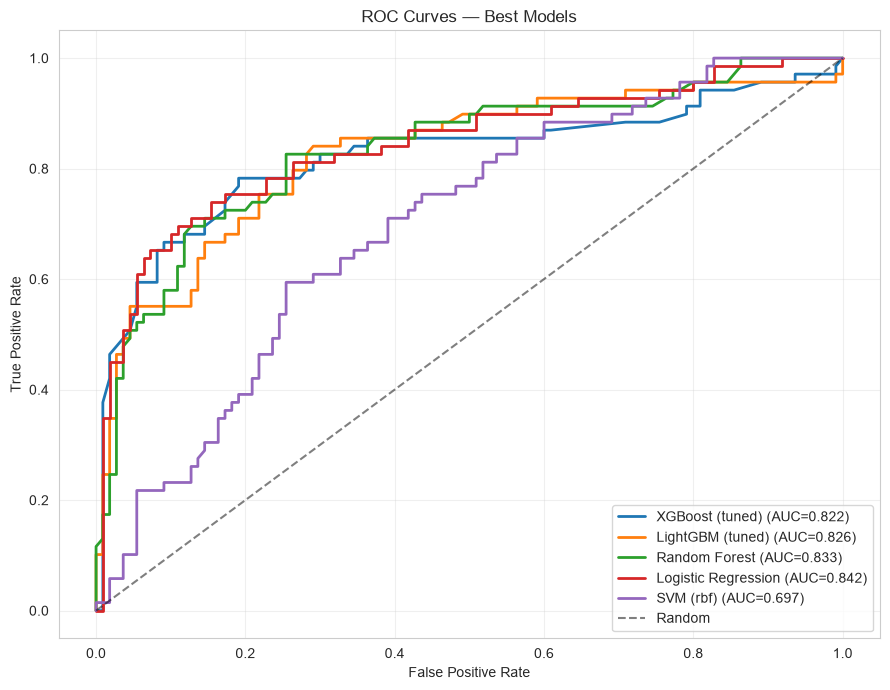

In [20]:
plt.figure(figsize=(9, 7))

top_models = [
    ("XGBoost (tuned)", best_xgb),
    ("LightGBM (tuned)", best_lgbm),
    ("Random Forest", rf),
    ("Logistic Regression", logreg),
    ("SVM (rbf)", svm),
]

for name, model in top_models:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Best Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

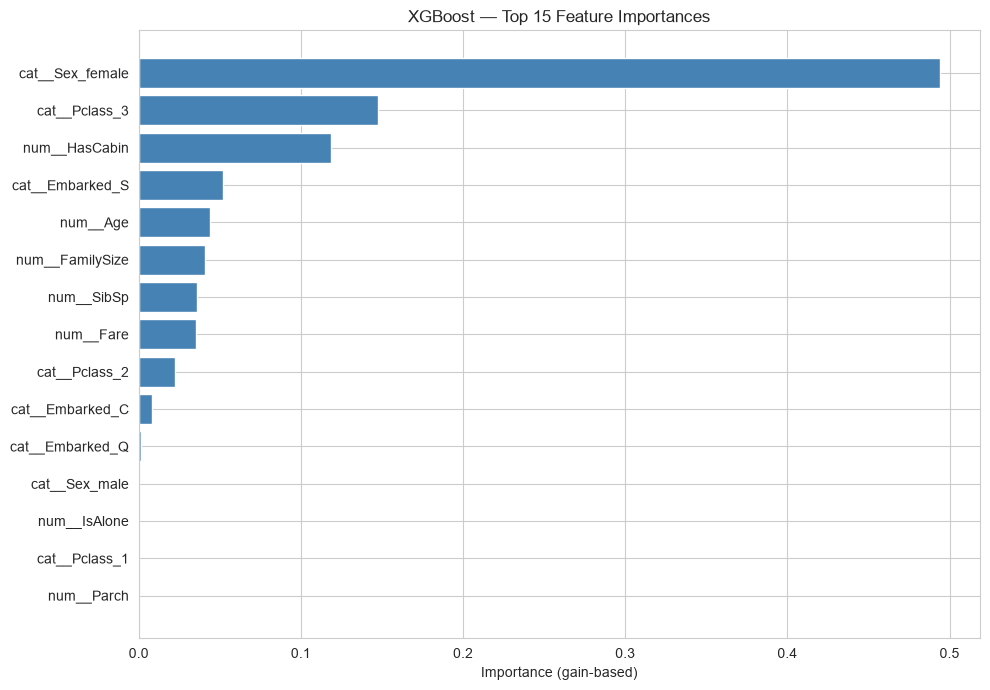

In [21]:
# XGBoost provides feature importance via .feature_importances_
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()
importances = best_xgb.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
plt.xlabel("Importance (gain-based)")
plt.title("XGBoost — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
import shap 
xgb_model = best_xgb.named_steps["model"]

X_test_preprocessed = best_xgb.named_steps["preprocessor"].transform(X_test)
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_preprocessed)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.show()


## Summary — The Full Supervised Learning Picture

### All models we've built

| Model | Type | Interpretability | Speed | Typical Rank |
|-------|------|------------------|-------|--------------|
| Logistic Regression | Linear | High | Fast | Baseline |
| Decision Tree | Non-linear | Very High | Fast | Weak alone |
| Random Forest | Ensemble (bagging) | Medium | Medium | Strong |
| KNN | Instance-based | Low | Slow predict | Medium |
| SVM (rbf) | Margin-based | Low | Slow | Strong (small data) |
| XGBoost | Ensemble (boosting) | Medium | Fast | **Best** |
| LightGBM | Ensemble (boosting) | Medium | **Fastest** | **Best** |

### Key takeaways

1. **Boosting > Bagging** on most tabular data.
2. **No single model wins everywhere** — always benchmark.
3. **Feature engineering** matters more than model choice in many cases.
4. **Hyperparameters + CV** are non-negotiable for good results.
5. **SHAP** turns black-box models into explainable ones.

### When to use what

| Situation | Model |
|-----------|-------|
| Need coefficient interpretation | Logistic Regression |
| Need decision rules | Decision Tree (shallow) |
| Need black-box accuracy | XGBoost / LightGBM |
| Very large data | LightGBM |
| Small data (<1000) | SVM, Logistic Regression |
| High-dim sparse (text) | Logistic Regression, Linear SVM |
| Need to explain predictions | XGBoost + SHAP |

## 🚀 Next

→ [../04-unsupervised-learning/01-kmeans-hierarchical-dbscan.ipynb](../04-unsupervised-learning/01-kmeans-hierarchical-dbscan.ipynb)

**You've completed supervised learning.** Time for unsupervised.

In [22]:
import joblib

joblib.dump(best_xgb, "xgb_titanic.joblib")
joblib.dump(best_lgbm, "lgbm_titanic.joblib")
print("Saved: xgb_titanic.joblib, lgbm_titanic.joblib")

Saved: xgb_titanic.joblib, lgbm_titanic.joblib


In [23]:
# Final summary — write to file for documentation
summary = f"""
# Supervised Learning — Final Report

## Best model: {leaderboard.iloc[0]['Model']}
- Accuracy: {leaderboard.iloc[0]['Accuracy']:.4f}
- F1: {leaderboard.iloc[0]['F1']:.4f}
- ROC-AUC: {leaderboard.iloc[0]['ROC-AUC']:.4f}

## All models (sorted by ROC-AUC):
{leaderboard.round(4).to_string(index=False)}
"""

with open("supervised_summary.md", "w") as f:
    f.write(summary)

print(summary)


# Supervised Learning — Final Report

## Best model: Logistic Regression
- Accuracy: 0.8156
- F1: 0.7442
- ROC-AUC: 0.8422

## All models (sorted by ROC-AUC):
               Model  Accuracy     F1  ROC-AUC
 Logistic Regression    0.8156 0.7442   0.8422
  LightGBM (default)    0.7877 0.7206   0.8376
       Random Forest    0.7933 0.7218   0.8331
    LightGBM (tuned)    0.7709 0.6822   0.8263
   XGBoost (default)    0.7877 0.7121   0.8250
     XGBoost (tuned)    0.8045 0.7107   0.8221
KNN (k=11, distance)    0.7151 0.6107   0.7428
      SVM (rbf, C=1)    0.6257 0.3232   0.6974

